# Exploratory Data Analysis

## Import required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import calendar

## Load the dataset

In [2]:
DATA_PATH = Path("../data/processed/clean_data.csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["Order Date", "Ship Date"]
)

## 1. Total Sales

In [3]:
total_sales = df["Sales"].sum()
print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,261,536.78


The total sales amounted to `$2,261,536.78`, indicating the overall revenue generated during the analyzed period.

## 2. Average Order Value

In [4]:
order_totals = df.groupby("Order ID")["Sales"].sum()
average_order = order_totals.mean()
print(f"Average Order Value: ${average_order:,.2f}")

Average Order Value: $459.48


The average order value was `$459.48`, showing the typical amount spent per order.

## 3. Monthly Sales

In [5]:
monthly_sales = df.resample("ME", on="Order Date")["Sales"].sum()

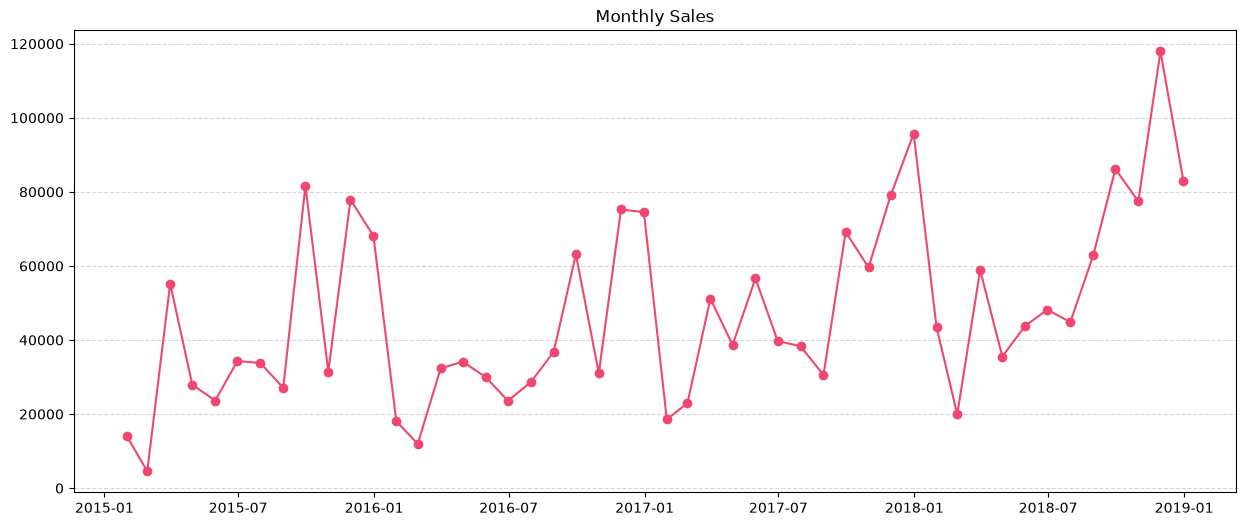

In [6]:
plt.figure(figsize=(15,6))

plt.plot(monthly_sales.index, monthly_sales.values, color="#EF476F", marker="o")

plt.title("Monthly Sales")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

The overall time series shows fluctuation across the full 2016–2018 period, with a general upward trend in total sales year over year. This chart shows the trend over *time*, not seasonality — to see which calendar months are consistently strongest or weakest regardless of year, sales need to be aggregated by month number across all years, done below.

### Seasonality by Calendar Month (all years combined)

In [7]:
monthly_seasonality = df.groupby(df["Order Date"].dt.month)["Sales"].sum()
monthly_seasonality.index = [calendar.month_abbr[m] for m in monthly_seasonality.index]

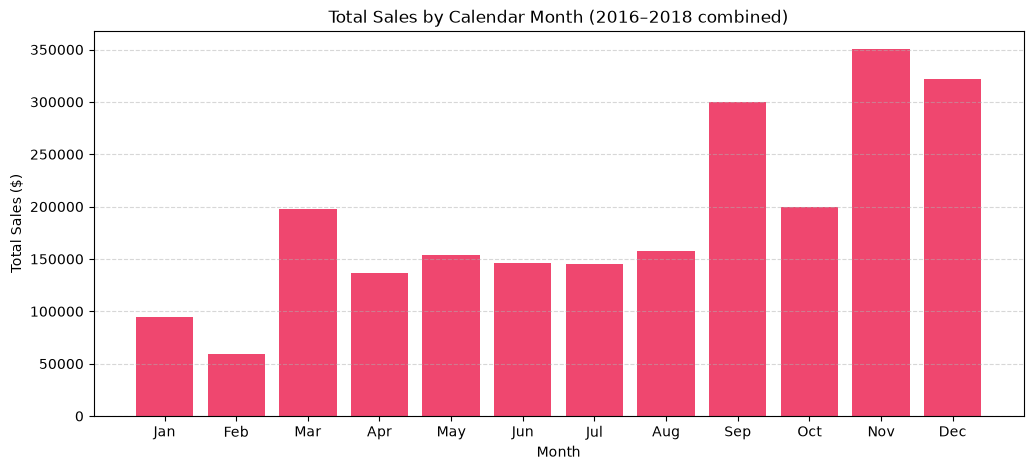

In [8]:
plt.figure(figsize=(12, 5))

plt.bar(monthly_seasonality.index, monthly_seasonality.values, color="#EF476F")

plt.title("Total Sales by Calendar Month (2016–2018 combined)")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

Aggregated across all years, sales are clearly seasonal rather than evenly spread: `November` (~$350K), `September` (~$300K), and `December` (~$320K) are the strongest months. `February` is the weakest month (~$60K), followed by `January` (~$95K). The mid-year months (`April`–`August`) are comparatively flat, ranging roughly $135K–$160K, with no strong seasonal pull in either direction.

This is a genuine recurring seasonal pattern — distinct from the year-over-year growth trend observed in the time series above.

## 4. Sales by Categories

In [9]:
sales_by_categories = (df.groupby("Category")["Sales"]
                    .sum()
                    .sort_values(ascending=False)
)

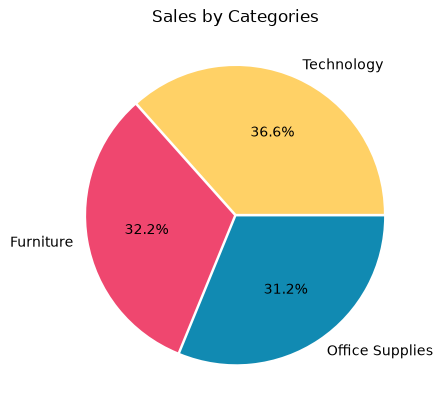

In [10]:
colors = ["#FFD166", "#EF476F", "#118AB2"]
explode = (0.01, 0.01, 0.01)

plt.pie(sales_by_categories.values, labels=sales_by_categories.index, autopct="%1.1f%%", colors=colors, explode=explode)

plt.title("Sales by Categories")

plt.show()

The sales distribution across categories is fairly balanced, although `Technology` has a slightly larger share than the other categories.

## 5. Sales Distribution by Category

In [11]:
distribution_by_categories = [
    df[df["Category"] == category]["Sales"]
    for category in df["Category"].unique()
]

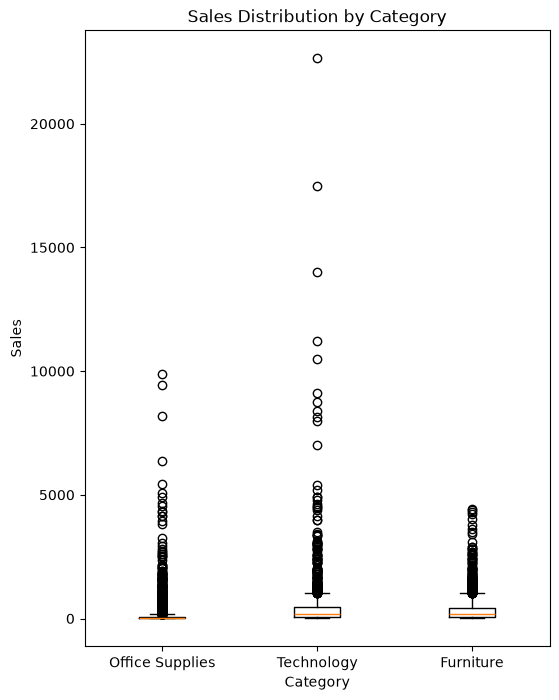

In [12]:
plt.figure(figsize=(6, 8))

plt.boxplot(distribution_by_categories, tick_labels=df["Category"].unique())

plt.title("Sales Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

All three categories exhibit a strongly right-skewed distribution with numerous outliers (individual very high-value orders) — the median is significantly lower than the mean.

## 8. Top 10 Products

In [13]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

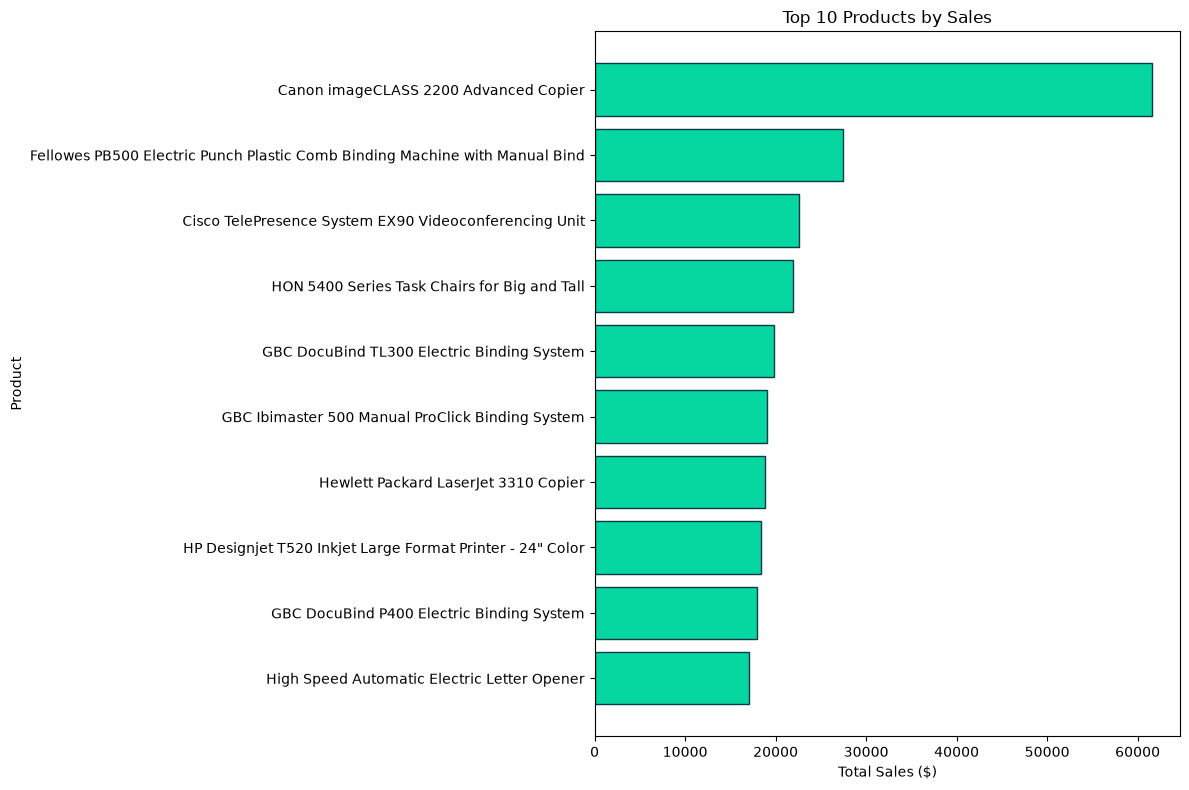

In [14]:
plt.figure(figsize=(12, 8))

plt.barh(top_products.index, top_products.values, color="#06d6a0", edgecolor="#073B4C")

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

`Canon imageCLASS 2200 Advanced Copier` clearly stands out with significantly higher total sales than the rest.

## 7. Sales by Segments

In [15]:
sales_by_segments = (df.groupby("Segment")["Sales"]
                    .sum()
                    .sort_values(ascending=False)
                    )

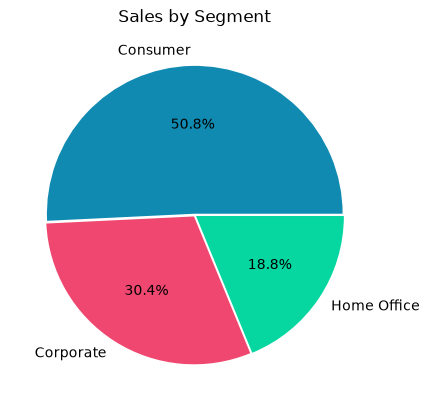

In [16]:
colors = ["#118AB2", "#EF476F", "#06D6A0"]
explode = (0.01, 0.01, 0.01)

plt.pie(sales_by_segments.values, labels=sales_by_segments.index, 
        autopct="%1.1f%%", colors=colors, explode=explode)

plt.title("Sales by Segment")

plt.show()

The `Consumer` segment is clearly the largest, followed by the `Corporate` segment, with the `Home office` segment being the smallest.

## 8. Top Cities

In [17]:
top_cities = (df.groupby(["City", "State"])["Sales"]
              .sum()
              .sort_values(ascending=False)
              .head(10)
              )
top_cities.index = [f"{city}, {state}" for city, state in top_cities.index]

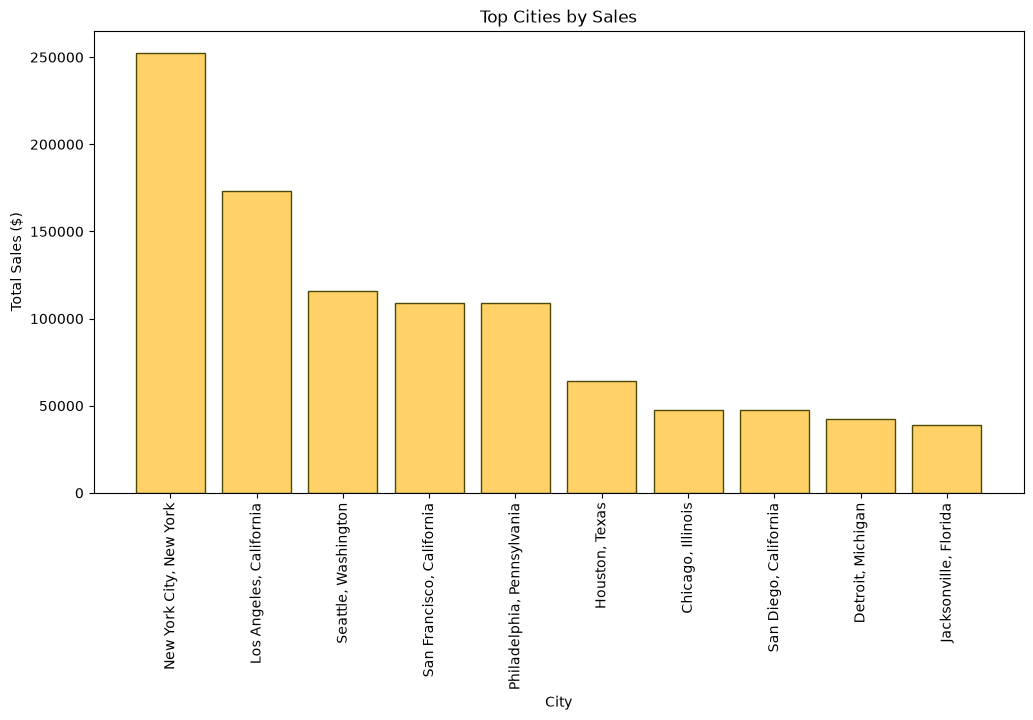

In [18]:
plt.figure(figsize=(12, 6))

plt.bar(top_cities.index, top_cities.values, color="#FFD166", edgecolor="#4C4907")

plt.title("Top Cities by Sales")
plt.ylabel("Total Sales ($)")
plt.xlabel("City")
plt.xticks(rotation=90)

plt.show()

The highest sales were generated in `New York City`, indicating strong market performance in this location.

## 9. Heatmap: Sales by Region and Category

In [19]:
pivot = pd.pivot_table(
    df,
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

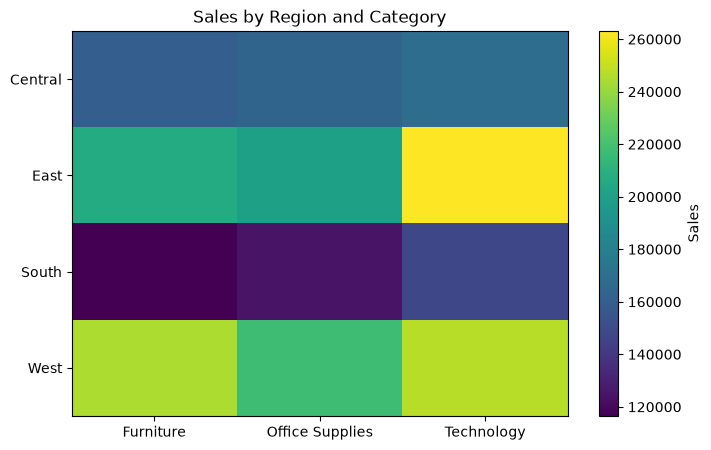

In [20]:
plt.figure(figsize=(8, 5))

plt.imshow(pivot, aspect="auto")

plt.colorbar(label="Sales")

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.title("Sales by Region and Category")

plt.show()

The heatmap shows that sales performance varies across regions and categories. The strongest combination is `East` – `Technology`, while the weakest is `South` – `Furniture`.

## 10. The best Customer

In [21]:
best_customer = (df.groupby(["Customer ID", "Customer Name"], as_index=False)["Sales"]
                 .sum()
                 .sort_values("Sales",ascending=False)
                 .head(1)
                 )

display(best_customer)

,Customer ID,Customer Name,Sales
700,SM-20320,Sean Miller,25043.05


`Sean Miller` generated the highest total sales, making them the most valuable customer in the dataset.

## Key Insights

- **Revenue**: Total sales reached **$2,261,536.78** over the analyzed period, with an average order value of **$459.48**.
- **Trend & seasonality**:  Sales show a general upward trend over the period, with clear seasonality — `November`, `December`, and `September` are the strongest months (~$300K–$350K), while `February` and `January` are the weakest (~$60K–$95K).
- **Categories**: Sales are fairly balanced across `Technology`, `Office Supplies`, and `Furniture`, with `Technology` slightly ahead; all three show a right-skewed distribution driven by a small number of high-value orders.
- **Products**: The `Canon imageCLASS 2200 Advanced Copier` is a standout top performer, well above the next best-selling products.
- **Segments**: The `Consumer` segment drives the largest share of sales, ahead of `Corporate` and `Home Office`.
- **Geography**: `New York City, New York` leads all locations in sales; the `East`–`Technology` combination is the strongest region–category pair, `South`–`Furniture` the weakest.
- **Customers**: Value is not spread evenly — `Sean Miller` is the top individual customer.
